# Лабораторная №3. Многослойная нейронная сеть
**Задание:**
1)	Реализовать многослойную нейронную сеть с минимум 1 скрытым слоем (из 2+ нейронов) и выходным слоем с 1 нейроном для задачи XOR.Посмотреть лекцию и сайт: (https://robocraft.ru/algorithm/560).Посмотреть нейронку на сайте: (https://playground.tensorflow.org/).Задать случайные весовые параметры и обучить нейронную сеть для задачи XOR. Можно использовать пороговую функцию активации или sigmoid (можно другие). Проверить учится ли многослойная нейронная сеть на прошлых задачах AND и OR. Многослойная нейронная сеть должна учиться для всех 3-х задач: AND, OR и XOR. Все нейроны в сети должны учиться одновременно (Нельзя обучать один нейрон скрытого слоя на AND, второй на OR и склеивать в XOR. Все нейроны сети должны учиться одновременно (чисто на основе входных и выходных данных), смотреть алгоритм в видео лекции и на сайте (https://robocraft.ru/algorithm/560)).
2)	Реализовать многослойную нейронную сеть с минимум 1 скрытым слоем (из 25+ нейронов) и одним выходным слоем из 10 нейронов, для распознавания рукописных цифр MNIST (каждый нейрон выходного слоя распознает только свою цифру, то есть один нейрон распознает только 0, второй 1, третий 2 и т.д.). Модифицировать первую программу для задачи XOR. Для повышения точности предлагается использовать функцию активации sigmoid и настроить скорость обучения нейронной сети (можно реализовать функцию активации relu для скрытого слоя и т.п. по желанию). Вычислить MSE (квадратическую ошибку), в процессе обучения должна уменьшаться. Добиться точности больше 50% для всех классов цифр (случайное угадывание составляет 10%).
3) Реализовать многослойную нейронную сеть на Keras (Документация: https://keras.io/, Пример с рукописными цифрами MNIST: https://keras.io/examples/vision/mnist_convnet/). (разобраться в коде Keras и сравнить свою реализацию с реализацией Keras на одной топологии нейронной сети).
4) Нарисовать свою картинку цифры в Paint и подать в программу для распознавания (в свою нейронную сеть и в нейронку на Keras).

Пояснение:
-	Первая часть задания для отладки программы, на ней проще понять и отладить алгоритм обучения многослойной нейронной сети (на простой задаче).
-	Вторая часть небольшая практическая задача, можно реализовать доработав первый алгоритм с задачи XOR.
-	Третья часть для сравнения своей реализации и реализации нейронной сети на библиотеке Keras. Можно сравнить точность и удобство работы, скорость реализации и т.д. Дан пример реализации: (https://keras.io/examples/vision/mnist_convnet/).
-	Четвертая часть для понимания, что алгоритм действительно работает и можно подавать свои данные. Также вырабатывает понимание, как подавать свои данные в нейронную сеть. Будут вопросы на понимание: что такое нейрон, как обучается нейронная сеть, что такое скрытый слой, как вычислили формулы для обучения нейронной сети.

**В помощь**
Основы нейронных сетей:
1) Сайт с подробным алгоритмом обучения нейронной сети в картинках: (https://robocraft.ru/algorithm/560). Описаны прямой проход (ответ нейронной сети на входные данные) и обратный проход (обучение нейронной сети).
2) Курс на Stepic: (https://stepik.org/lesson/21778/step/1?unit=5195). Глава: «3  Алгоритм обратного распространения ошибки».

Основы Keras:
3) Документация Keras: (https://keras.io/).
4) Пример с рукописными цифрами MNIST: (https://keras.io/examples/vision/mnist_convnet/).


## Импорт библиотек

In [1]:
import numpy as np
import keras
import cv2
import matplotlib.pyplot as plt

## Задание 1

Данные для модели

In [2]:
features = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
])
labels_xor = np.array([0, 1, 1, 0]).reshape(4, 1)
labels_and = np.array([0, 0, 0, 1]).reshape(4, 1)
labels_or  = np.array([0, 1, 1, 1]).reshape(4, 1)

Функция точности (accuracy)

In [3]:
def accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()

Класс нейронной сети

In [4]:
class NeuralNetwork:
    '''
    Принимает:
    lr:      float     - скорость обучения
    epochs:  int       - колличество эпох
    neurons: list(int) - список из кол-ва нейронов в каждом 
    слое (с учетом выходного), число входных параметров не входит

    У скрытых слоев функции активации - ReLu,
    у выходного - sigmoid
    '''
    def __init__(
            self, 
            lr:      float     = 0.01, # скорость обучения
            epochs:  int       = 10,   # число эпох
            neurons: list[int] = [10]  # число нейронов на каждом слое (скрытые + выход)
    ):
        self.lr           = lr
        self.epochs       = epochs
        self.neurons      = neurons
        self.count_layers = len(self.neurons) # число слоев
    

    ''' ФУНКЦИИ АКТИВАЦИИ '''

    def _sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    
    def _relu(self, Z):
        return np.where(Z >= 0, Z, 0)

    
    ''' ОБУЧЕНИЕ МОДЕЛИ '''

    def _init_params(self, d: int):
        ''' Инициализация начальных весов и смещений '''
        self.weights = [] # список весов каждого слоя
        self.bias    = [] # список смещений каждого слоя
        
        for i in range(self.count_layers):      # проходим по каждому слою
            m = self.neurons[i]                 # число нейронов
            k = self.neurons[i - 1] if i else d # число признаков

            # матрица весов для i слоя
            w = (np.random.randn(m ,k) * 0.1).astype(np.float32)

            # вектор смещений для i слоя
            b = np.zeros(m, dtype=np.float32) 

            self.weights.append(w)
            self.bias.append(b)
            

    def _forward(self, X):
        '''
        Прямой проход по сети
        '''
        self.cache = []
        A          = X.copy()
        for i in range(self.count_layers): # проходим по каждому слою
            Z     = A @ self.weights[i].T + self.bias[i]
            A_new = (
                self._relu(Z)                     # для внутренних слоев
                if i < self.count_layers - 1 else # не выходной слой
                self._sigmoid(Z)                  # для выходного слоя
            )
            self.cache.append((A, Z, A_new))
            A = A_new
        return A
            

    def _backward(self, pred, y):
        ''' 
        Обратный проход по сети
        ''' 
        # При бинарной классификации и сигмоиде используем бинарную кросс энтропию:
        # L = - (y * log(y_pred) + (1 - y) * log(1 - y_pred))
        # dL / dy_pred = (-y) / (y_pred) + (1 - y) / (1 - y_pred) = 
        # = (y_pred - y) / (y_pred * (1 - y_pred))
        # y_pred = σ(z)
        # dy_pred / dz = σ(z) * (1 - σ(z)) = y_pred * (1 - y_pred)
        # dL / dz = dL / dy_pred * dy_pred / dz = y_pred - y
        n = y.shape[0] # число объектов

        # Не Numpy так как число нейронов в слоях может отличаться
        self.grad_w = [None] * self.count_layers
        self.grad_b = [None] * self.count_layers

        err = (pred - y) / n # (n,)

        for i in reversed(range(self.count_layers)):
            A_prev, Z, A = self.cache[i]

            # Градиенты по весам и смещениям
            self.grad_w[i] = err.T @ A_prev
            self.grad_b[i] = err.sum(axis=0)

            if i > 0:
                err    = err @ self.weights[i]
                Z_prev = self.cache[i - 1][1]
                err   *= (Z_prev > 0)


    def fit(self, X, y):
        # Инициализация случайных весов для каждого слоя
        n, d = X.shape # n - число объектов, d - число признаков
        self._init_params(d)

        for epoch in range(self.epochs):
            # Прямой и обратный проходы
            pred = self._forward(X)
            self._backward(pred, y)

            # Корректировка весов
            for i in range(self.count_layers):
                self.weights[i] -= self.lr * self.grad_w[i]
                self.bias[i]    -= self.lr * self.grad_b[i]

            # Выводы во время обучения
            BCEntropy = -1 * (y * np.log(pred) + (1 - y) * np.log(1 - pred)).mean()
            print(f'Эпоха {epoch + 1}: BCE = {BCEntropy:.2f}')


    """ ПРЕДСКАЗАНИЯ """

    def predict_proba(self, X):
        return self._forward(X)
        
    
    def predict(self, X):
        return (self.predict_proba(X) > 0.5).astype(np.uint8)


Инициализация и тренировка сетей

In [5]:
nn_or = NeuralNetwork(
    lr      = 0.1,
    epochs  = 500,
    neurons = [2, 1]
)
nn_or.fit(features, labels_or)

Эпоха 1: BCE = 0.69
Эпоха 2: BCE = 0.69
Эпоха 3: BCE = 0.68
Эпоха 4: BCE = 0.68
Эпоха 5: BCE = 0.67
Эпоха 6: BCE = 0.67
Эпоха 7: BCE = 0.66
Эпоха 8: BCE = 0.66
Эпоха 9: BCE = 0.65
Эпоха 10: BCE = 0.65
Эпоха 11: BCE = 0.64
Эпоха 12: BCE = 0.64
Эпоха 13: BCE = 0.64
Эпоха 14: BCE = 0.63
Эпоха 15: BCE = 0.63
Эпоха 16: BCE = 0.63
Эпоха 17: BCE = 0.62
Эпоха 18: BCE = 0.62
Эпоха 19: BCE = 0.62
Эпоха 20: BCE = 0.62
Эпоха 21: BCE = 0.61
Эпоха 22: BCE = 0.61
Эпоха 23: BCE = 0.61
Эпоха 24: BCE = 0.61
Эпоха 25: BCE = 0.60
Эпоха 26: BCE = 0.60
Эпоха 27: BCE = 0.60
Эпоха 28: BCE = 0.60
Эпоха 29: BCE = 0.60
Эпоха 30: BCE = 0.60
Эпоха 31: BCE = 0.59
Эпоха 32: BCE = 0.59
Эпоха 33: BCE = 0.59
Эпоха 34: BCE = 0.59
Эпоха 35: BCE = 0.59
Эпоха 36: BCE = 0.59
Эпоха 37: BCE = 0.59
Эпоха 38: BCE = 0.59
Эпоха 39: BCE = 0.59
Эпоха 40: BCE = 0.58
Эпоха 41: BCE = 0.58
Эпоха 42: BCE = 0.58
Эпоха 43: BCE = 0.58
Эпоха 44: BCE = 0.58
Эпоха 45: BCE = 0.58
Эпоха 46: BCE = 0.58
Эпоха 47: BCE = 0.58
Эпоха 48: BCE = 0.58
Э

In [6]:
nn_and = NeuralNetwork(
    lr      = 0.1,
    epochs  = 500,
    neurons = [5, 1]
)
nn_and.fit(features, labels_and)

Эпоха 1: BCE = 0.69
Эпоха 2: BCE = 0.69
Эпоха 3: BCE = 0.68
Эпоха 4: BCE = 0.68
Эпоха 5: BCE = 0.67
Эпоха 6: BCE = 0.67
Эпоха 7: BCE = 0.66
Эпоха 8: BCE = 0.66
Эпоха 9: BCE = 0.65
Эпоха 10: BCE = 0.65
Эпоха 11: BCE = 0.64
Эпоха 12: BCE = 0.64
Эпоха 13: BCE = 0.64
Эпоха 14: BCE = 0.63
Эпоха 15: BCE = 0.63
Эпоха 16: BCE = 0.63
Эпоха 17: BCE = 0.62
Эпоха 18: BCE = 0.62
Эпоха 19: BCE = 0.62
Эпоха 20: BCE = 0.62
Эпоха 21: BCE = 0.61
Эпоха 22: BCE = 0.61
Эпоха 23: BCE = 0.61
Эпоха 24: BCE = 0.61
Эпоха 25: BCE = 0.61
Эпоха 26: BCE = 0.60
Эпоха 27: BCE = 0.60
Эпоха 28: BCE = 0.60
Эпоха 29: BCE = 0.60
Эпоха 30: BCE = 0.60
Эпоха 31: BCE = 0.60
Эпоха 32: BCE = 0.59
Эпоха 33: BCE = 0.59
Эпоха 34: BCE = 0.59
Эпоха 35: BCE = 0.59
Эпоха 36: BCE = 0.59
Эпоха 37: BCE = 0.59
Эпоха 38: BCE = 0.59
Эпоха 39: BCE = 0.59
Эпоха 40: BCE = 0.59
Эпоха 41: BCE = 0.58
Эпоха 42: BCE = 0.58
Эпоха 43: BCE = 0.58
Эпоха 44: BCE = 0.58
Эпоха 45: BCE = 0.58
Эпоха 46: BCE = 0.58
Эпоха 47: BCE = 0.58
Эпоха 48: BCE = 0.58
Э

In [7]:
nn_xor = NeuralNetwork(
    lr      = 0.1,
    epochs  = 1000,
    neurons = [5, 1]
)
nn_xor.fit(features, labels_xor)

Эпоха 1: BCE = 0.69
Эпоха 2: BCE = 0.69
Эпоха 3: BCE = 0.69
Эпоха 4: BCE = 0.69
Эпоха 5: BCE = 0.69
Эпоха 6: BCE = 0.69
Эпоха 7: BCE = 0.69
Эпоха 8: BCE = 0.69
Эпоха 9: BCE = 0.69
Эпоха 10: BCE = 0.69
Эпоха 11: BCE = 0.69
Эпоха 12: BCE = 0.69
Эпоха 13: BCE = 0.69
Эпоха 14: BCE = 0.69
Эпоха 15: BCE = 0.69
Эпоха 16: BCE = 0.69
Эпоха 17: BCE = 0.69
Эпоха 18: BCE = 0.69
Эпоха 19: BCE = 0.69
Эпоха 20: BCE = 0.69
Эпоха 21: BCE = 0.69
Эпоха 22: BCE = 0.69
Эпоха 23: BCE = 0.69
Эпоха 24: BCE = 0.69
Эпоха 25: BCE = 0.69
Эпоха 26: BCE = 0.69
Эпоха 27: BCE = 0.69
Эпоха 28: BCE = 0.69
Эпоха 29: BCE = 0.69
Эпоха 30: BCE = 0.69
Эпоха 31: BCE = 0.69
Эпоха 32: BCE = 0.69
Эпоха 33: BCE = 0.69
Эпоха 34: BCE = 0.69
Эпоха 35: BCE = 0.69
Эпоха 36: BCE = 0.69
Эпоха 37: BCE = 0.69
Эпоха 38: BCE = 0.69
Эпоха 39: BCE = 0.69
Эпоха 40: BCE = 0.69
Эпоха 41: BCE = 0.69
Эпоха 42: BCE = 0.69
Эпоха 43: BCE = 0.69
Эпоха 44: BCE = 0.69
Эпоха 45: BCE = 0.69
Эпоха 46: BCE = 0.69
Эпоха 47: BCE = 0.69
Эпоха 48: BCE = 0.69
Э

Тесты

In [8]:
print(f'OR: {accuracy(labels_or, nn_or.predict(features))}')
print(f'AND: {accuracy(labels_and, nn_and.predict(features))}')
print(f'XOR: {accuracy(labels_xor, nn_xor.predict(features))}')


OR: 0.75
AND: 1.0
XOR: 0.75


## Задание 2

Получаем данные

In [9]:
def vectorize(x):
    return x.reshape(-1, 28*28)

def normalize(x):
    return x.astype(np.float32) / 255.0

In [10]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = normalize(vectorize(x_train))
x_test  = normalize(vectorize(x_test))
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

Модифицируем нейронную сети из предыдущего задания

In [11]:
class MNISTNeuralNetwork(NeuralNetwork):
    '''
    Принимает:
    lr:         float     - скорость обучения
    epochs:     int       - колличество эпох
    neurons:    list(int) - список из кол-ва нейронов в каждом слое (с учетом выходного)
    batch_size: int       - размер батча

    У скрытых слоев функции активации - ReLu,
    у выходного - softmax
    '''
    def __init__(
            self, 
            lr:         float     = 0.01,
            epochs:     int       = 10,
            neurons:    list[int] = [10],
            batch_size: int       = 10,
    ):
        # переиспользуем инициализацию lr/epochs/neurons/count_layers из базового класса
        super().__init__(lr=lr, epochs=epochs, neurons=neurons)
        self.bs = batch_size


    ''' ФУНКЦИИ АКТИВАЦИИ '''

    def _softmax(self, Z):
        max_z = np.max(Z, axis=1, keepdims=True)
        exp_z = np.exp(Z - max_z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # ReLu из базового класса

    ''' ОБУЧЕНИЕ МОДЕЛИ '''

    def _forward(self, X):
        '''
        Прямой проход по сети
        '''
        # Меняем функцию активации второго слоя на softmax
        self.cache = []
        A          = X.copy()
        for i in range(self.count_layers): # проходим по каждому слою
            Z     = A @ self.weights[i].T + self.bias[i]
            A_new = (
                self._relu(Z)                     # для внутренних слоев
                if i < self.count_layers - 1 else # не выходной слой
                self._softmax(Z)                  # для выходного слоя
            )
            self.cache.append((A, Z, A_new))
            A = A_new
        return A

    # backward без изменений

    def cross_entropy(self, P, Y):
        eps = 1e-12 # чтобы log(0) не ушел к inf
        return -np.sum(Y * np.log(P + eps), axis=1)


    def fit(self, X, Y):
        # Инициализация случайных весов для каждого слоя
        n, d = X.shape # n - число объектов, d - число признаков
        self._init_params(d)

        for epoch in range(self.epochs):
            # Добавляем батчи
            idx = np.random.permutation(n)

            epoch_loss = 0.0
            for i in range(0, n, self.bs):
                # получаем батч
                batch_indexes = idx[i:i + self.bs]
                X_batch = X[batch_indexes]      # (B, 784)
                Y_batch = Y[batch_indexes]      # (B, 10)
                B = X_batch.shape[0]
            
                # Прямой и обратный проходы
                pred = self._forward(X_batch)
                self._backward(pred, Y_batch)

                # Корректировка весов
                for j in range(self.count_layers):
                    self.weights[j] -= self.lr * self.grad_w[j]
                    self.bias[j]    -= self.lr * self.grad_b[j]

                epoch_loss += self.cross_entropy(pred, Y_batch).sum()

            # Выводы во время обучения
            epoch_loss /= n
            acc = ((self.predict(X) > 0.5).astype(np.uint8)  == Y).mean()
            print(f'Эпоха {epoch + 1}: loss={epoch_loss:.4f}, acc={acc:.4f}')

    ''' ПРЕДСКАЗАНИЯ '''
    def predict(self, X):
        return self._forward(X)


In [12]:
nn = MNISTNeuralNetwork(
    lr         = 0.1,
    batch_size = 128,
    epochs     = 20,
    neurons    = [32, 64, 10]
)
nn.fit(x_train, y_train)

Эпоха 1: loss=0.6358, acc=0.9804
Эпоха 2: loss=0.2883, acc=0.9860
Эпоха 3: loss=0.2235, acc=0.9889
Эпоха 4: loss=0.1872, acc=0.9900
Эпоха 5: loss=0.1642, acc=0.9910
Эпоха 6: loss=0.1468, acc=0.9924
Эпоха 7: loss=0.1332, acc=0.9916
Эпоха 8: loss=0.1226, acc=0.9936
Эпоха 9: loss=0.1130, acc=0.9939
Эпоха 10: loss=0.1053, acc=0.9941
Эпоха 11: loss=0.0983, acc=0.9949
Эпоха 12: loss=0.0928, acc=0.9950
Эпоха 13: loss=0.0880, acc=0.9946
Эпоха 14: loss=0.0831, acc=0.9955
Эпоха 15: loss=0.0792, acc=0.9959
Эпоха 16: loss=0.0754, acc=0.9960
Эпоха 17: loss=0.0717, acc=0.9962
Эпоха 18: loss=0.0680, acc=0.9964
Эпоха 19: loss=0.0665, acc=0.9966
Эпоха 20: loss=0.0630, acc=0.9968


In [13]:
accuracy(y_test, (nn.predict(x_test) > 0.5).astype(np.uint8))

np.float64(0.9936)

## Задание 3

In [14]:
nn_keras = keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
nn_keras.compile(loss="categorical_crossentropy", metrics=['accuracy'])
nn_keras.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8683 - loss: 0.4745 - val_accuracy: 0.9375 - val_loss: 0.2185
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.9302 - loss: 0.2415 - val_accuracy: 0.9518 - val_loss: 0.1742
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step - accuracy: 0.9453 - loss: 0.1907 - val_accuracy: 0.9610 - val_loss: 0.1428
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - accuracy: 0.9535 - loss: 0.1581 - val_accuracy: 0.9647 - val_loss: 0.1227
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step - accuracy: 0.9603 - loss: 0.1364 - val_accuracy: 0.9665 - val_loss: 0.1114
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - accuracy: 0.9640 - loss: 0.1207 - val_accuracy: 0.9692 - val_loss: 0.1049
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.9675 - loss: 0.1089 - val_accuracy: 0.9697 - val_loss: 0.1007
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - accuracy: 0.9705 - loss: 0.0994 - va

Сравнение моделей

In [15]:
print(f'Моя сеть:   accuracy = ', 
      f'{accuracy(y_test, (nn.predict(x_test) > 0.5).astype(np.uint8)):.4f}'
)
print(f'Сеть keras: accuracy = ', 
      f'{accuracy(y_test, (nn_keras.predict(x_test) > 0.5).astype(np.uint8)):.4f}'
)

Моя сеть:   accuracy =  0.9936
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step
Сеть keras: accuracy =  0.9932


## Задание 4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


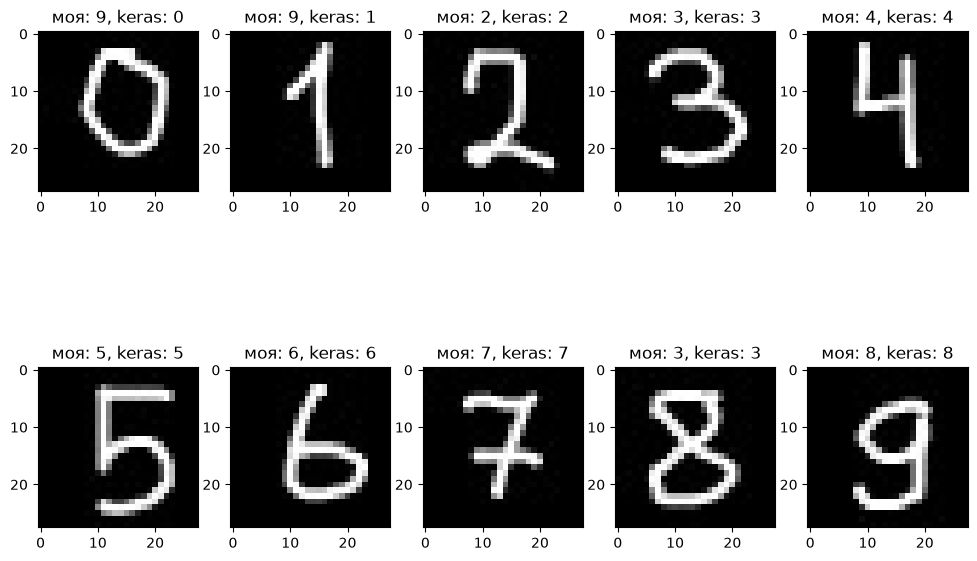

In [16]:
_, axes = plt.subplots(2, 5, figsize=(12,8))

for ax, i in zip(axes.ravel(), [i for i in range (10)]):
    img   = cv2.imread(f"./images/{i}.jpg", cv2.IMREAD_GRAYSCALE)
    img_n = normalize(vectorize(img))
    nn_pred       = nn.predict(img_n).argmax()
    nn_keras_pred = nn_keras.predict(img_n).argmax()
    ax.set_title(f'моя: {nn_pred}, keras: {nn_keras_pred}')
    ax.imshow(img, cmap='gray')
plt.show()